<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn13tl_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 학습된 대형모델(백본)인 MobileNet v2를 전이학습하여 cifa10 dataset을 분류하기
# 전이학습(Transfer Learning) - 이미 학습된 모델을 일부 재학습하여 내가 가진 새 데이터에 활용하기
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

NUM_CLASSES = 10
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('train data : ', x_train.shape) # (50000, 32, 32, 3)
print('test data : ', x_test.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
train data :  (50000, 32, 32, 3)
test data :  (10000, 32, 32, 3)


In [2]:
# 전이학습 : 기존 모델(백본)의 가중치는 모두 동결(freeze)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),  # 입력 크기 96, 128, 160, 192, 22 등을 지원
    include_top=False,  # MobileNetV2의 분류기 부분을 뺌. 컨볼루션 레이어만 남김
    weights='imagenet', # 사전 학습된 가중치 호출(120만 이미지, 1000개의 클래스)
)

base_model.trainable = False    # MobileNetV2은 학습에 참여하지 않도록 동결
print(base_model.summary())
# Total params: 2,257,984 (8.61 MB)
# Trainable params: 0 (0.00 B)
# Non-trainable params: 2,257,984 (8.61 MB)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [3]:
# MobileNetV2을 이용해 새로운 모델 생성
inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Resizing(128, 128)(inputs)    # cifar10 이미지를 MobileNetV2에 맞게 리사이징
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)   # MaxPooling2D보다 더 급격하게 feature의 크기를 줄임
outputs = tf.keras.layers.Dense(units=NUM_CLASSES, activation='softmax')(x)

model_tl = tf.keras.Model(inputs=inputs, outputs=outputs)
print(model_tl.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [4]:
model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model_tl.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss , acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'model_tl => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/10
625/625 - 46s - 74ms/step - accuracy: 0.7008 - loss: 0.8711 - val_accuracy: 0.7558 - val_loss: 0.7021
Epoch 2/10
625/625 - 12s - 20ms/step - accuracy: 0.7757 - loss: 0.6468 - val_accuracy: 0.7748 - val_loss: 0.6471
Epoch 3/10
625/625 - 14s - 23ms/step - accuracy: 0.7918 - loss: 0.5952 - val_accuracy: 0.7806 - val_loss: 0.6335
Epoch 4/10
625/625 - 12s - 20ms/step - accuracy: 0.8021 - loss: 0.5689 - val_accuracy: 0.7837 - val_loss: 0.6285
Epoch 5/10
625/625 - 12s - 20ms/step - accuracy: 0.8117 - loss: 0.5458 - val_accuracy: 0.7912 - val_loss: 0.6005
Epoch 6/10
625/625 - 12s - 20ms/step - accuracy: 0.8152 - loss: 0.5276 - val_accuracy: 0.7886 - val_loss: 0.6127
Epoch 7/10
625/625 - 13s - 20ms/step - accuracy: 0.8203 - loss: 0.5172 - val_accuracy: 0.7824 - val_loss: 0.6371
Epoch 8/10
625/625 - 12s - 20ms/step - accuracy: 0.8233 - loss: 0.5085 - val_accuracy: 0.7822 - val_loss: 0.6248
Epoch 9/10
625/625 - 12s - 20ms/step - accuracy: 0.8252 - loss: 0.4976 - val_accuracy: 0.7872 - 

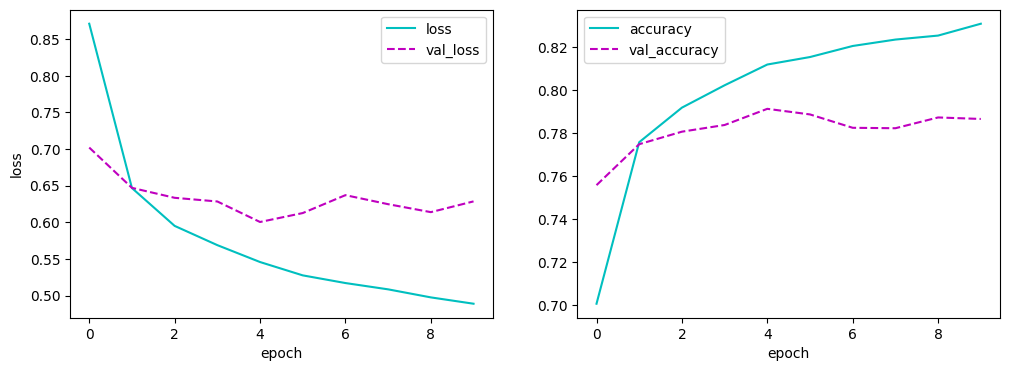

In [6]:
import matplotlib.pyplot as plt
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'c-', label='loss')
plt.plot(history.history['val_loss'], 'm--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'c-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'm--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [7]:
# 미세 조정(Fine Tunning) - 전이 학습 이후 성능 향상을 위해 기존모델(백본)의 일부 층을 학습에 참여시킴
# optimizer는 원래의 기본값을 사용하면 안된다! - leaning_rate를 매우 적게 줘야함!

base_model.trainable = True # 모델 전체 학습에 참여 가능하게 열어 놓고
# 뒤에 10개의 층만 참여시킴 - 마지막 10개를 제외하고 동결
for layer in base_model.layers[:-10]:
  layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss , acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'model_tl => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/10
625/625 - 33s - 52ms/step - accuracy: 0.5256 - loss: 2.0203 - val_accuracy: 0.7152 - val_loss: 0.9411
Epoch 2/10
625/625 - 14s - 22ms/step - accuracy: 0.6145 - loss: 1.4723 - val_accuracy: 0.6828 - val_loss: 1.1756
Epoch 3/10
625/625 - 14s - 22ms/step - accuracy: 0.6629 - loss: 1.2278 - val_accuracy: 0.6860 - val_loss: 1.1857
Epoch 4/10
625/625 - 14s - 22ms/step - accuracy: 0.6883 - loss: 1.0925 - val_accuracy: 0.6903 - val_loss: 1.1514
Epoch 5/10
625/625 - 14s - 23ms/step - accuracy: 0.7095 - loss: 1.0055 - val_accuracy: 0.6987 - val_loss: 1.1066
Epoch 6/10
625/625 - 14s - 23ms/step - accuracy: 0.7177 - loss: 0.9496 - val_accuracy: 0.7090 - val_loss: 1.0608
Epoch 7/10
625/625 - 14s - 23ms/step - accuracy: 0.7317 - loss: 0.8964 - val_accuracy: 0.7162 - val_loss: 1.0228
Epoch 8/10
625/625 - 14s - 23ms/step - accuracy: 0.7380 - loss: 0.8652 - val_accuracy: 0.7248 - val_loss: 0.9924
Epoch 9/10
625/625 - 14s - 23ms/step - accuracy: 0.7464 - loss: 0.8340 - val_accuracy: 0.7294 - 